# Notebook 05 — Analyse de cadrage VSS × Immigration

## Objectif

Ce notebook est le **cœur de l'analyse**. On cherche à déterminer comment chaque bloc politique **cadre** la relation entre les violences sexistes/sexuelles (VSS) et l'immigration/les minorités religieuses dans les débats à l'Assemblée Nationale.

Pour chaque phrase qui mentionne à la fois les VSS et l'immigration, on classe le cadrage en trois catégories :
- **ACCUSATEUR** : l'orateur présente l'immigration/l'islam comme la *cause* ou le *responsable* des VSS
- **VICTIME** : l'orateur présente les immigrés/minorités comme *victimes* de violences ou de discriminations
- **NEUTRE** : mention administrative, factuelle, ou dénonciation explicite de l'amalgame VSS-immigration

## Les 4 méthodes (par ordre de sophistication)

| # | Méthode | Principe | Forces | Faiblesses |
|---|---------|----------|--------|------------|
| V1 | Lexique de cadrage-menace | Score basé sur des listes de mots de causalité/accusation/menace | Rapide, explicable | Aveugle au sens ("musulmans agressés" = même score que "musulmans agressent") |
| V2 | Patterns orientés rôle | Regex syntaxiques (sujet-verbe-objet) pour détecter qui est agent vs victime | Capture la direction causale | Rigide, ne couvre pas toutes les tournures |
| V3 | Zero-shot NLI | Modèle Transformer (CamemBERT NLI) pour classification sémantique sans entraînement | Comprend le sens | Dépend du prompt, plus lent |
| V4 | Classification LLM | Llama 3.3 via le serveur Ollama de l'ENSAE analyse chaque phrase | Le plus précis, avec justification | Très lent (~3h), dépend du serveur |

## Entrées
- `df_vss_propre.pkl` (notebook 02)

## Sorties
- CSV des phrases classifiées avec justification (une par méthode)
- Graphiques : barres empilées, score net, évolution temporelle, heatmap par parti
- Exemples qualitatifs par bloc pour validation

---
## 0. Imports et chargement des données
---

In [1]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, time
from collections import defaultdict, Counter
from tqdm import tqdm

# Chargement des données
# On charge le fichier EXACT produit par le Testfile original
# Chemin identique à celui du Testfile (cellules 7, 12, 17, etc.)
chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"

# Fallback : si le fichier n'est pas à la racine, on cherche dans dataframes/
import os
if not os.path.exists(chemin_propre):
    chemin_propre = CHEMIN_DF_VSS_PROPRE  # depuis config.py
if not os.path.exists(chemin_propre):
    print(f"❌ ERREUR : df_vss_propre.pkl introuvable.")
    print(f"   Cherché dans : /home/onyxia/work/projet_eco_socio/df_vss_propre.pkl")
    print(f"   Et dans : {CHEMIN_DF_VSS_PROPRE}")

df_vss = pd.read_pickle(chemin_propre)
df_vss['date'] = pd.to_datetime(df_vss['date'])
df_vss = df_vss.dropna(subset=['bloc']).copy()

print(f"✅ {len(df_vss)} prises de parole VSS chargées.")
print(f"   Répartition par bloc :")
for bloc in ORDRE_BLOCS:
    n = len(df_vss[df_vss['bloc'] == bloc])
    print(f"     {bloc:30s} : {n:5d}")

# Fallback si config.py n'est pas importé correctement
import os
if 'DOSSIER_ANALYSES' not in dir():
    BASE_DIR = "/home/onyxia/work/projet_eco_socio"
    DOSSIER_ANALYSES = os.path.join(BASE_DIR, "analyses")
    os.makedirs(DOSSIER_ANALYSES, exist_ok=True)
if 'ORDRE_BLOCS' not in dir():
    ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
    COULEURS_BLOCS = {"Extrême Droite": "#8B0000", "Droite Traditionnelle": "#1E3A8A", "Centre": "#D97706", "Gauche Modérée": "#166534", "Gauche Radicale": "#DC2626"}


✅ 7815 prises de parole VSS chargées.
   Répartition par bloc :
     Extrême Droite                 :   726
     Droite Traditionnelle          :  1470
     Centre                         :  2815
     Gauche Modérée                 :  1115
     Gauche Radicale                :  1689


### Constantes graphiques communes

On définit ici les couleurs et l'ordre des blocs, utilisés dans toutes les visualisations.

In [2]:
# Déjà importé depuis config.py, mais on rappelle pour clarté :
# ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]
# COULEURS_BLOCS = {"Extrême Droite": "#8B0000", "Droite Traditionnelle": "#1E3A8A", ...}

# Vocabulaire identitaire/migratoire — élargi pour maximiser la couverture
GROUPES_CIBLES = [
    # Immigration directe
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    # Mots composés et acronymes administratifs
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    # Religion / Culture
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    # Origines / Civilisation
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    # Lexique sécuritaire
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]

# Vocabulaire VSS — élargi pour ne pas manquer de cooccurrences
MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

print(f"✅ {len(GROUPES_CIBLES)} racines identitaires, {len(MOTS_VSS)} racines VSS.")

✅ 36 racines identitaires, 28 racines VSS.


---
## 1. Extraction des phrases de co-occurrence VSS × Immigration
---

Avant d'appliquer les 4 méthodes de classification, il faut **extraire** les phrases pertinentes du corpus. On utilise deux modes complémentaires :

1. **Mode direct** : les deux vocabulaires (VSS et identitaire) apparaissent dans la **même phrase**.
2. **Mode fenêtre** : un mot VSS dans une phrase, un mot identitaire dans une phrase **voisine** (±2 phrases). Cela capture les cas où l'orateur parle de VSS dans une phrase puis mentionne l'immigration juste après.

Cette extraction est commune aux 4 méthodes.

In [3]:
def extraire_contextes(df_vss, fenetre_phrases=2):
    """
    Extrait les contextes où VSS et groupe cible (immigration/religion) se croisent.

    Deux modes :
    - 'directe' : les deux vocabulaires dans la même phrase
    - 'fenetre' : vocabulaire VSS dans une phrase, groupe cible dans une phrase voisine

    Args:
        df_vss: DataFrame des prises de parole VSS
        fenetre_phrases: nombre de phrases voisines à inspecter (défaut: 2)

    Returns:
        DataFrame avec colonnes [contexte, bloc, nom_parti, date, mode]
    """
    pat_groupe = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b"
    )
    pat_vss = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS]) + r")\w*\b"
    )

    print("🔍 Extraction des contextes VSS × immigration...")
    resultats = []

    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Filtrage"):
        texte = str(row.get("texte", ""))
        bloc = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue

        # Découpage en phrases
        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)

        for i, phrase in enumerate(phrases):
            a_vss = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))

            if a_vss and a_groupe:
                # Mode direct : les deux thématiques dans la même phrase
                resultats.append({
                    "contexte": phrase, "bloc": bloc,
                    "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                    "mode": "directe"
                })
            elif a_vss:
                # Mode fenêtre : VSS dans cette phrase, groupe cible dans une voisine
                debut = max(0, i - fenetre_phrases)
                fin = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    contexte_elargi = " ".join(phrases[debut:fin])
                    resultats.append({
                        "contexte": contexte_elargi, "bloc": bloc,
                        "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                        "mode": "fenetre"
                    })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")

    print(f"\n✅ {len(df)} contextes extraits.")
    print(f"   Modes : {df['mode'].value_counts().to_dict()}")
    print(f"   Par bloc :")
    for bloc in ORDRE_BLOCS:
        n = len(df[df['bloc'] == bloc])
        if n > 0:
            print(f"     {bloc:30s} : {n}")

    return df

In [4]:
# Extraction (utilisée par toutes les méthodes)
df_contextes = extraire_contextes(df_vss, fenetre_phrases=2)

🔍 Extraction des contextes VSS × immigration...


Filtrage: 100%|██████████| 7815/7815 [00:06<00:00, 1202.61it/s]


✅ 588 contextes extraits.
   Modes : {'fenetre': 350, 'directe': 238}
   Par bloc :
     Extrême Droite                 : 108
     Droite Traditionnelle          : 103
     Centre                         : 149
     Gauche Modérée                 : 71
     Gauche Radicale                : 157


### Fonctions de visualisation communes

Ces fonctions sont réutilisées par chacune des 4 méthodes pour assurer une présentation homogène des résultats.

In [5]:
def tracer_barres_empilees(df, col_cadrage, titre="", output_dir=None):
    """
    Barres 100% empilées : répartition ACCUSATEUR / NEUTRE / VICTIME par bloc.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (df.groupby(["bloc", col_cadrage]).size()
              .unstack(fill_value=0).reindex(blocs_presents))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME", "AMBIGU"]:
        if col not in pct.columns:
            pct[col] = 0

    coul = {"ACCUSATEUR": "#C0392B", "AMBIGU": "#E67E22",
            "NEUTRE": "#95A5A6", "VICTIME": "#2980B9"}

    fig, ax = plt.subplots(figsize=(12, 7))
    bottom = np.zeros(len(pct))
    cats = [c for c in ["ACCUSATEUR", "AMBIGU", "NEUTRE", "VICTIME"] if c in pct.columns and pct[c].sum() > 0]
    for cat in cats:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul.get(cat, "gray"),
               label=cat, edgecolor="white", lw=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottom += vals
    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)")
    ax.set_title(titre, fontsize=13, fontweight="bold")
    ax.legend(title="Cadrage", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    if output_dir:
        nom_fichier = re.sub(r'[^a-zA-Z0-9]', '_', titre[:40]) + ".png"
        plt.savefig(os.path.join(output_dir, nom_fichier), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_score_net(df, col_score, titre="", output_dir=None):
    """
    Score net moyen par bloc (ACCUSATEUR=+1, VICTIME=-1) avec barres d'erreur.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    stats = (df.groupby("bloc")[col_score]
             .agg(["mean", "sem", "count"])
             .rename(columns={"mean": "m", "sem": "e", "count": "n"})
             .reset_index())
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    couleurs = [COULEURS_BLOCS.get(b, "gray") for b in stats["bloc"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"], color=couleurs,
            edgecolor="white", capsize=4,
            error_kw={"elinewidth": 1.5, "ecolor": "#333", "capthick": 1.5})
    ax.axvline(0, color="black", lw=1.5)
    ax.axvspan(-1.5, 0, alpha=0.04, color="blue")
    ax.axvspan(0, 1.5, alpha=0.04, color="red")
    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x >= 0 else "right", fontsize=9)
    ax.set_title(titre, fontsize=13, fontweight="bold")
    ax.set_xlabel("← protecteur / victime  |  accusateur →")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    if output_dir:
        nom_fichier = re.sub(r'[^a-zA-Z0-9]', '_', titre[:40]) + ".png"
        plt.savefig(os.path.join(output_dir, nom_fichier), dpi=150, bbox_inches="tight")
    plt.show()


def tracer_evolution(df, col_score, titre="", output_dir=None):
    """
    Évolution annuelle du score net par bloc.
    """
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    d = df.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])

    evol = d.groupby(["annee", "bloc"])[col_score].mean().reset_index()
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(13, 7))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty:
            continue
        ax.plot(sub["annee"], sub[col_score], marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "gray"), lw=2.5, markersize=7)

    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5)
    ax.set_title(titre, fontsize=13, fontweight="bold")
    ax.set_xlabel("Année")
    ax.set_ylabel("Score net moyen")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(ls="--", alpha=0.4)
    plt.tight_layout()
    if output_dir:
        nom_fichier = re.sub(r'[^a-zA-Z0-9]', '_', titre[:40]) + ".png"
        plt.savefig(os.path.join(output_dir, nom_fichier), dpi=150, bbox_inches="tight")
    plt.show()


def afficher_exemples(df, col_cadrage, n=2):
    """
    Validation qualitative : exemples par bloc et par cadrage.
    """
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE — exemples par bloc")
    print("=" * 80)

    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty:
            continue
        col_score = [c for c in df.columns if "score_net" in c or "score" in c]
        score_col = col_score[0] if col_score else None
        score_str = f", score net moyen : {sub[score_col].mean():.3f}" if score_col else ""

        print(f"\n{'─'*65}")
        print(f"  {bloc.upper()} — {len(sub)} contextes{score_str}")
        print(f"  {sub[col_cadrage].value_counts().to_dict()}")

        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub[col_cadrage] == cadrage].head(n)
            if sous.empty:
                continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = str(row["contexte"])[:250]
                print(f"    [{row.get('nom_parti', '?')}] \"{txt}...\"")
                if "justification" in row and pd.notna(row.get("justification")):
                    print(f"    → {str(row['justification'])[:150]}")
    print()

---
## 2. Méthode V1 — Lexique de cadrage-menace (score lexical)
---

### Principe

On définit un **dictionnaire de patterns linguistiques** regroupés en 4 catégories :
- **Causalité directe** : "à cause de l'immigration", "importé", "commis par des étrangers"...
- **Accusation de groupe** : "les immigrés", "leur culture", "ces étrangers"...
- **Rhétorique de la menace** : "invasion", "ensauvagement", "nos femmes", "insécurité"...
- **Opposition nous/eux** : "chez nous", "nos valeurs", "leur conception"...

Chaque catégorie a un **poids** (causalité=3, accusation=2, menace=2, nous/eux=1). Le score total d'une phrase est la somme pondérée des détections.

### Limites
Cette méthode est **aveugle au sens syntaxique**. "Les musulmans sont agressés" et "Les musulmans agressent" produisent le même score, ce qui motive la méthode V2.

In [6]:
# Lexique du "cadrage-menace"
CADRAGE_MENACE = {
    "causalite": [
        "à cause de", "en raison de", "provoqué par", "causé par", "viennent de",
        "importé", "importée", "venu d'ailleurs", "venu de l'étranger",
        "rapporté", "lié à l'immigration", "lié aux migrants",
        "due à l'immigration", "dû à l'immigration", "issus de l'immigration",
        "issu de l'immigration", "commis par des", "perpétré par des",
        "commis par des étrangers", "auteurs étrangers", "agresseurs étrangers"
    ],
    "accusation_groupe": [
        "les immigrés", "ces étrangers", "ces migrants", "les clandestins",
        "ces hommes venus", "certaines cultures", "certaines religions",
        "communautés", "les musulmans", "leur culture", "leur religion",
        "leur pays d'origine", "leurs coutumes", "pratiques culturelles",
        "pratiques religieuses", "mentalité", "vision de la femme"
    ],
    "rhetorique_menace": [
        "invasion", "submersion", "grand remplacement", "ensauvagement",
        "insécurité", "danger", "menace", "protéger", "défendre",
        "nos femmes", "nos filles", "notre pays", "notre identité",
        "laxisme", "permissivité", "frontières ouvertes", "immigration incontrôlée"
    ],
    "nous_eux": [
        "chez nous", "en france", "notre société", "nos valeurs",
        "leur conception", "leur rapport", "contrairement à nous",
        "n'ont pas les mêmes", "mentalité différente",
        "pays d'origine", "culture d'origine"
    ]
}

POIDS_CATEGORIES = {"causalite": 3, "accusation_groupe": 2, "rhetorique_menace": 2, "nous_eux": 1}

# Lexique de sentiment pour score hostile vs intersectionnel
SENTIMENT_HOSTILE = [
    "responsable", "coupable", "fautif", "auteur", "agresseur", "violeur",
    "commis", "perpétré", "banalisé", "toléré", "importé",
    "danger", "dangereux", "risque", "menace", "insécurité",
    "sauvagerie", "barbare", "primitif", "expulser", "renvoyer",
    "inadmissible", "inacceptable", "intolérable",
]

SENTIMENT_INTERSECTIONNEL = [
    "accompagner", "protéger", "aider", "soutenir", "accueillir",
    "doublement", "vulnérable", "précaire", "discriminé",
    "sans-papier", "sans titre", "irrégulier",
]

def calculer_score_menace(texte):
    texte_lower = texte.lower()
    score = 0
    details = defaultdict(list)
    for categorie, mots in CADRAGE_MENACE.items():
        for mot in mots:
            if mot.lower() in texte_lower:
                score += POIDS_CATEGORIES[categorie]
                details[categorie].append(mot)
    return score, dict(details)

def calculer_score_sentiment(texte):
    texte_lower = texte.lower()
    hostile = sum(1 for m in SENTIMENT_HOSTILE if m in texte_lower)
    intersect = sum(1 for m in SENTIMENT_INTERSECTIONNEL if m in texte_lower)
    total = hostile + intersect
    return (hostile - intersect) / total if total > 0 else 0.0

print("✅ Lexiques V1 définis.")

✅ Lexiques V1 définis.


In [7]:
# Application de la méthode V1
print("🔄 Application de la méthode V1 (lexique de cadrage-menace)...")

df_v1 = df_contextes.copy()

scores, details = zip(*df_v1['contexte'].apply(calculer_score_menace))
df_v1['score_menace'] = scores
df_v1['details_menace'] = [str(d) if d else "" for d in details]
df_v1['est_menace'] = df_v1['score_menace'] > 0
df_v1['score_sentiment'] = df_v1['contexte'].apply(calculer_score_sentiment)

# Score net simplifié : 1 si menace, -1 si intersectionnel, 0 sinon
df_v1['score_net_v1'] = np.where(
    df_v1['score_menace'] > 2, 1,
    np.where(df_v1['score_sentiment'] < -0.3, -1, 0)
)
df_v1['cadrage_v1'] = np.where(
    df_v1['score_menace'] > 2, "ACCUSATEUR",
    np.where(df_v1['score_sentiment'] < -0.3, "VICTIME", "NEUTRE")
)

print(f"\n📊 Distribution V1 :")
print(df_v1['cadrage_v1'].value_counts().to_string())

🔄 Application de la méthode V1 (lexique de cadrage-menace)...

📊 Distribution V1 :
cadrage_v1
NEUTRE        508
ACCUSATEUR     52
VICTIME        28


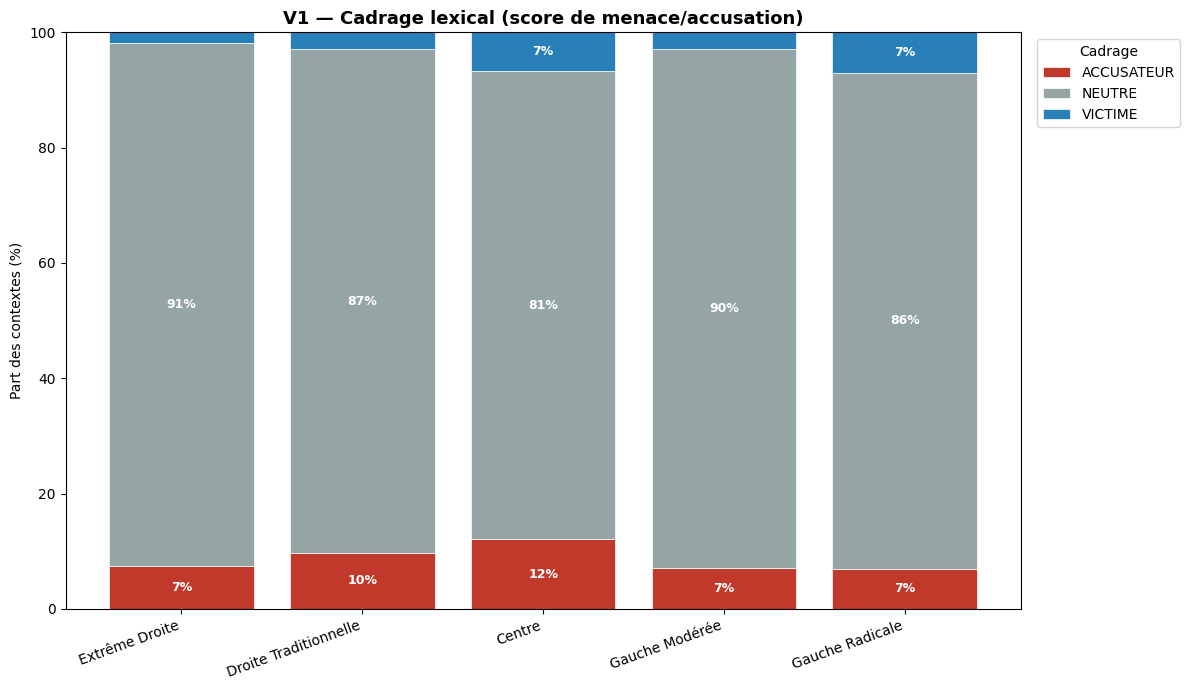

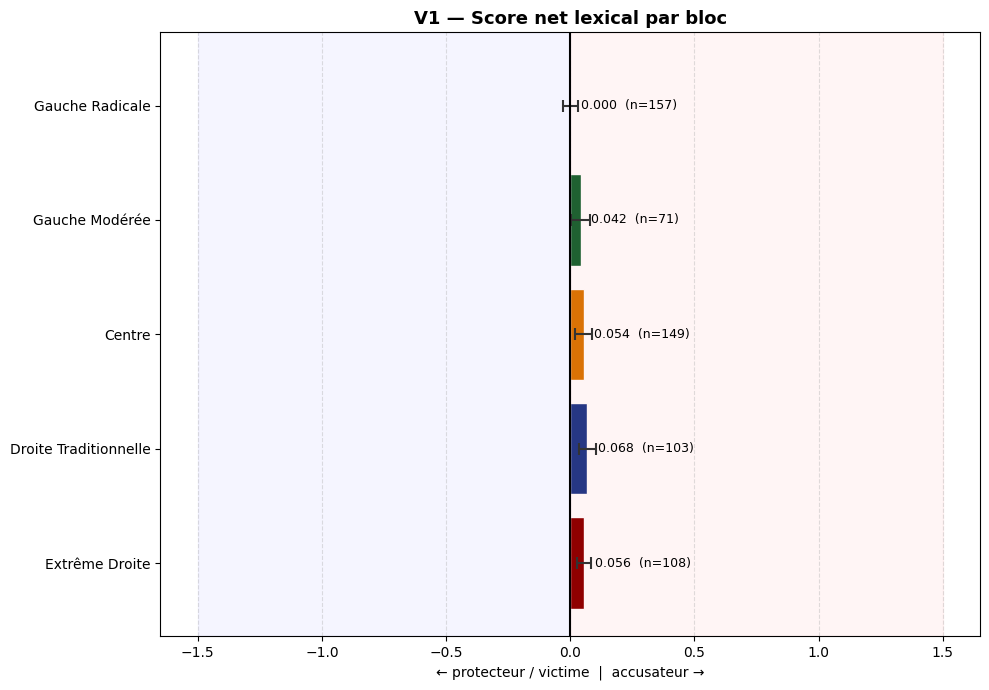

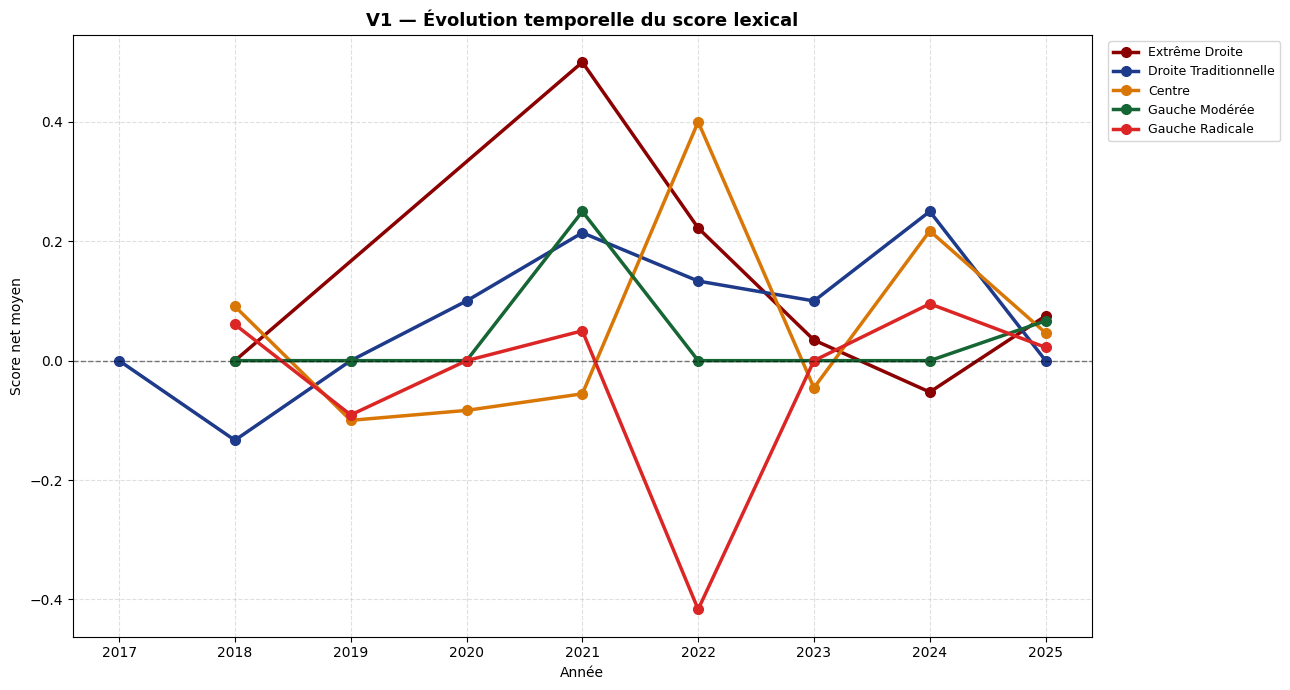


VALIDATION QUALITATIVE — exemples par bloc

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE — 108 contextes, score net moyen : 0.713
  {'NEUTRE': 98, 'ACCUSATEUR': 8, 'VICTIME': 2}

  [ACCUSATEUR]
    [Rassemblement national] "Parce que, si ce texte a vocation à défendre les principes de la République, les votes des députés du groupe La République en Marche sont, sans le moindre doute, révélateurs de l’idée qu’Emmanuel Macron se fait de l’évolution que doit connaître notre..."
    [Rassemblement national] "Et que dire de ces associations – financées par l’État – qui gèrent les logements d’urgence et qui refusent de mettre à la rue les déboutés du droit d’asile, eux-mêmes refusant de quitter le territoire national Pendant ce temps, certains des véritabl..."

  [VICTIME]
    [Rassemblement national] "Il ne réglerait pas la question de la montée de l’islamisme radical dans nos écoles mais il nous aiderait à le circonscrire, à le combattre, et ce n’est p

In [8]:
output_v1 = os.path.join(DOSSIER_ANALYSES, "cadrage_v1_lexique")

tracer_barres_empilees(df_v1, "cadrage_v1",
    titre="V1 — Cadrage lexical (score de menace/accusation)", output_dir=output_v1)
tracer_score_net(df_v1, "score_net_v1",
    titre="V1 — Score net lexical par bloc", output_dir=output_v1)
tracer_evolution(df_v1, "score_net_v1",
    titre="V1 — Évolution temporelle du score lexical", output_dir=output_v1)
afficher_exemples(df_v1, "cadrage_v1", n=2)

---
## 3. Méthode V2 — Patterns syntaxiques orientés rôle (regex)
---

### Principe

Le problème de V1, c'est que "Les musulmans sont agressés" et "Les musulmans agressent" produisent le même score. La V2 corrige cela en utilisant des **expressions régulières orientées sujet-verbe-objet** :

- **Patterns ACCUSATEUR** : le groupe cible est en position de **sujet/agent** d'un verbe d'agression, ou l'immigration est présentée comme **cause** des VSS
- **Patterns VICTIME** : le groupe cible est en position de **patient/objet** (il subit les violences), ou l'orateur dénonce l'amalgame

On mesure le nombre de patterns matchés de chaque type, et le score net = n_accusateur − n_victime.

In [9]:
PATTERNS_ACCUSATEUR = [
    # "[groupe] + verbe d'agression"
    r"(immigr\w*|clandestin\w*|étranger\w*|migrant\w*|musulman\w*|arabe\w*)"
    r"[\w\s,]{0,30}"
    r"(viol\w*|agress\w*|maltraitent|commettent|perpètrent|battent|frappent|tuent)",
    # "violences commises/perpétrées par [groupe]"
    r"(violences?|viols?|agressions?|féminicides?)"
    r"[\w\s,]{0,20}(commis|perpétr|fait|exerc)\w*"
    r"[\w\s,]{0,15}(immigr\w*|clandestin\w*|étranger\w*|musulman\w*|arabe\w*)",
    # "à cause de l'immigration"
    r"(à cause de|en raison de|du fait de|liés? à)"
    r"[\w\s]{0,20}(l.immigration|clandestin|leur culture|leur religion|l.islam)",
    # "importé / venu d'ailleurs"
    r"(import[ée]\w*|venu[e]? d.ailleurs|étranger[eès]? à notre|apporté\w*)",
    # "nos femmes/filles" + menace
    r"(nos femmes|nos filles|nos enfants)[\w\s,]{0,30}(protéger|défendre|menac\w*|danger)",
    # Mots-chocs
    r"(invasion|ensauvagement|grand remplacement|submersion|islamisation)",
    # "leur culture / mentalité / rapport à la femme"
    r"(leur culture|leur mentalité|leur rapport à la femme|leur vision de la femme"
    r"|leur conception de la femme|pratiques culturelles|pratiques religieuses)",
    # "[étranger] condamné pour viol"
    r"(étranger\w*|immigr\w*).{0,30}condamné\w*.{0,20}(viol|agress)",
]

PATTERNS_VICTIME = [
    # "[groupe] sont victimes / subissent"
    r"(immigr\w*|étranger\w*|migrant\w*|musulman\w*|sans-papier\w*|réfugié\w*)"
    r"[\w\s,]{0,30}(victimes?|subiss\w*|agress[ée]\w*|discrimin\w*|exposés?)",
    # "protéger les [groupe]"
    r"(protéger|défendre|accompagner|soutenir|aider)"
    r"[\w\s]{0,20}(immigr\w*|migrant\w*|sans-papier\w*|réfugiées?)",
    # "double vulnérabilité"
    r"(doublement|vulnérable|précaire|plus exposée|davantage exposée)",
    # Dénonciation d'amalgame
    r"(bouc[s]? émissaire[s]?|stigmatis\w*|diabolis\w*|montré[s]? du doigt)",
    r"(amalgam\w*|instrumentalis\w*|récupération (politique|électorale|identitaire))",
    # Réfutation
    r"(ne|n.?) (faut|peut|doit)\w* pas.{0,30}lien",
    r"(faux|mauvais|dangereux) (lien|raccourci|amalgame)",
]

def detecter_role_v2(phrase):
    phrase_lower = phrase.lower()
    n_acc = sum(1 for p in PATTERNS_ACCUSATEUR if re.search(p, phrase_lower, re.I | re.DOTALL))
    n_vic = sum(1 for p in PATTERNS_VICTIME if re.search(p, phrase_lower, re.I | re.DOTALL))
    score_net = n_acc - n_vic

    if n_acc == 0 and n_vic == 0:
        cadrage = "NEUTRE"
    elif n_acc > n_vic:
        cadrage = "ACCUSATEUR"
    elif n_vic > n_acc:
        cadrage = "VICTIME"
    else:
        cadrage = "AMBIGU"

    return {"n_accusateur": n_acc, "n_victime": n_vic, "score_net_v2": score_net, "cadrage_v2": cadrage}

print("✅ Patterns V2 définis.")

✅ Patterns V2 définis.


In [10]:
print("🔄 Application de la méthode V2 (patterns orientés rôle)...")

scores_v2 = df_contextes["contexte"].apply(detecter_role_v2)
df_v2 = pd.concat([df_contextes.reset_index(drop=True), pd.DataFrame(scores_v2.tolist())], axis=1)

print(f"\n📊 Distribution V2 :")
print(df_v2['cadrage_v2'].value_counts().to_string())

🔄 Application de la méthode V2 (patterns orientés rôle)...

📊 Distribution V2 :
cadrage_v2
NEUTRE        528
VICTIME        31
ACCUSATEUR     25
AMBIGU          4


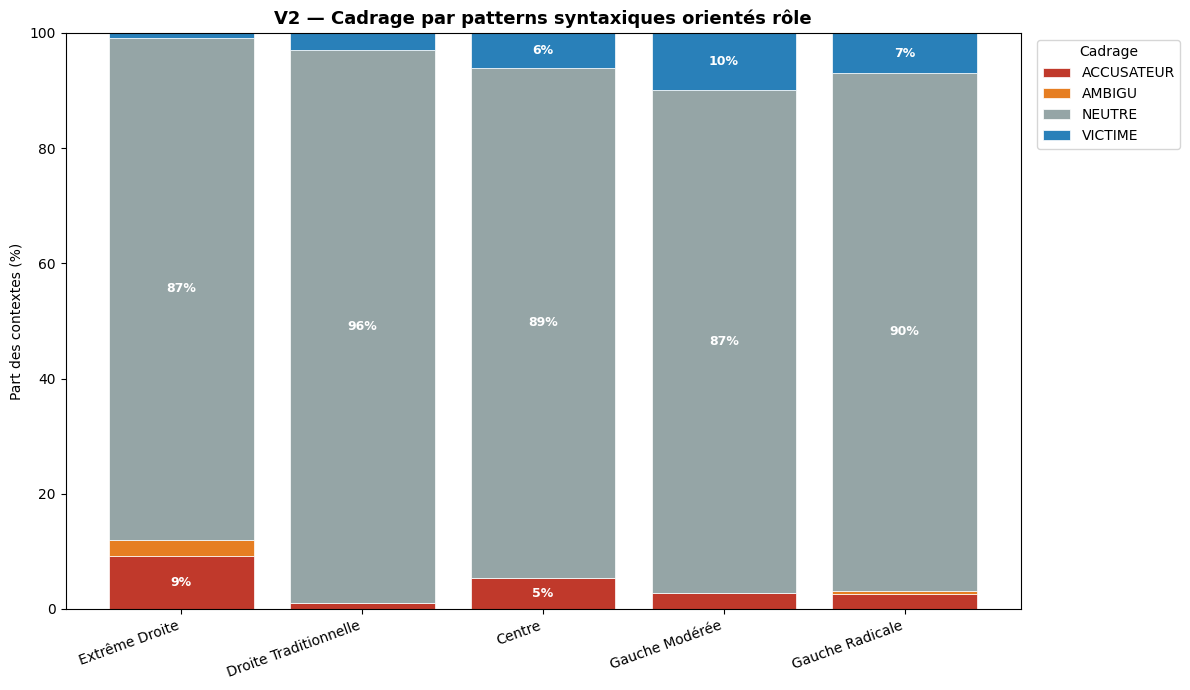

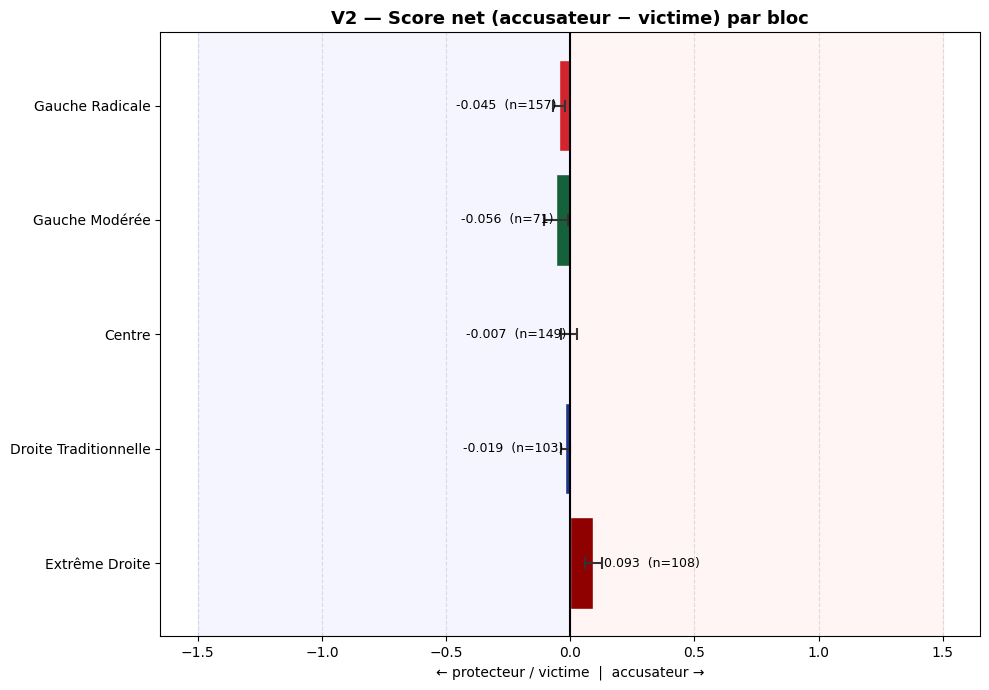

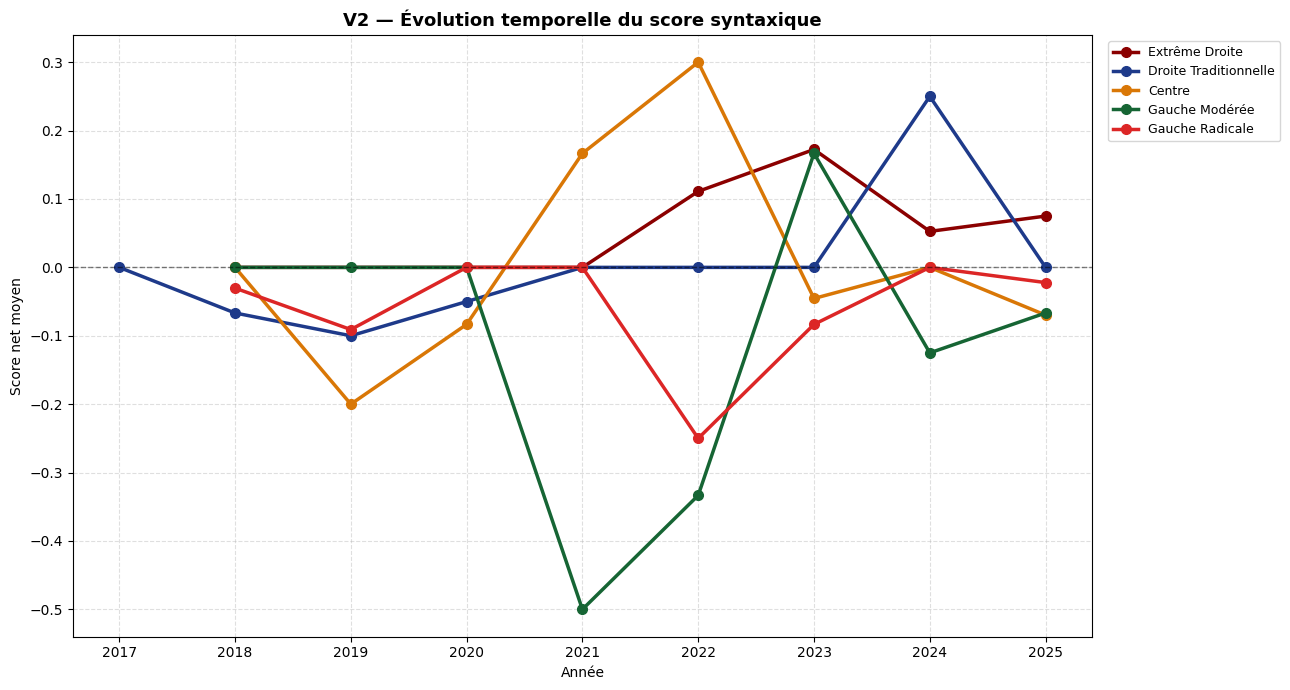


VALIDATION QUALITATIVE — exemples par bloc

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE — 108 contextes, score net moyen : 0.093
  {'NEUTRE': 94, 'ACCUSATEUR': 10, 'AMBIGU': 3, 'VICTIME': 1}

  [ACCUSATEUR]
    [Rassemblement national] "Et que dire de ces associations – financées par l’État – qui gèrent les logements d’urgence et qui refusent de mettre à la rue les déboutés du droit d’asile, eux-mêmes refusant de quitter le territoire national Pendant ce temps, certains des véritabl..."
    [Rassemblement national] "Cet amendement de Marine Le Pen entend inscrire le respect de tous les citoyens dans notre texte fondamental, au-delà des particularités qui peuvent certes les distinguer dans leur personnalité mais en aucun cas dans leur citoyenneté L’égalité de cha..."

  [VICTIME]
    [Rassemblement national] "Ces éléments tangibles viennent avec beaucoup, si ce n’est énormément, de communication, sur tous les sujets susceptibles d’émouvoir l’opini

In [11]:
output_v2 = os.path.join(DOSSIER_ANALYSES, "cadrage_v2_regex")

tracer_barres_empilees(df_v2, "cadrage_v2",
    titre="V2 — Cadrage par patterns syntaxiques orientés rôle", output_dir=output_v2)
tracer_score_net(df_v2, "score_net_v2",
    titre="V2 — Score net (accusateur − victime) par bloc", output_dir=output_v2)
tracer_evolution(df_v2, "score_net_v2",
    titre="V2 — Évolution temporelle du score syntaxique", output_dir=output_v2)
afficher_exemples(df_v2, "cadrage_v2", n=2)

---
## 4. Méthode V3 — Classification Zero-Shot (CamemBERT NLI)
---

### Principe

On utilise un modèle Transformer pré-entraîné sur des tâches d'**inférence en langage naturel** (NLI). Le modèle reçoit la phrase et trois hypothèses, et il attribue une probabilité à chacune :
- *"Ce texte présente l'immigration comme la cause des VSS"* → ACCUSATEUR
- *"Ce texte présente les immigrés comme victimes de violences"* → VICTIME
- *"Ce texte est neutre ou dénonce l'amalgame"* → NEUTRE

**Modèle choisi** : `cmarkea/distilcamembert-base-nli` — un CamemBERT distillé fine-tuné sur NLI en français.

### Avantages vs V2
- Comprend le **sens sémantique** de la phrase, pas juste des patterns de surface
- Gère les tournures implicites et les doubles négations

> **⏱ Temps estimé** : ~10-30 min selon le nombre de phrases et la disponibilité GPU.
> **Nécessite** : `pip install torch transformers sentencepiece`

In [12]:
import subprocess, sys

try:
    import torch
    from transformers import pipeline as hf_pipeline
    print(f"✅ PyTorch et Transformers disponibles. GPU : {torch.cuda.is_available()}")
except ImportError:
    print("⏳ Installation de torch et transformers...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch", "transformers", "sentencepiece"])
    import torch
    from transformers import pipeline as hf_pipeline
    print(f"✅ Installés. GPU : {torch.cuda.is_available()}")

✅ PyTorch et Transformers disponibles. GPU : False


In [13]:
# ==========================================================================
# CACHE : Si les résultats V3 existent, on les charge
# ==========================================================================

output_v3 = os.path.join(DOSSIER_ANALYSES, "cadrage_v3_zeroshot")
os.makedirs(output_v3, exist_ok=True)
chemin_v3_pkl = os.path.join(output_v3, "df_cadrage_v3.pkl")

if os.path.exists(chemin_v3_pkl):
    df_v3 = pd.read_pickle(chemin_v3_pkl)
    print(f"⏩ Résultats V3 chargés depuis le cache : {len(df_v3)} contextes.")
else:
    print("🔄 Chargement du modèle CamemBERT NLI...")
    device = 0 if torch.cuda.is_available() else -1

    classifier = hf_pipeline(
        "zero-shot-classification",
        model="cmarkea/distilcamembert-base-nli",
        device=device
    )
    print("✅ Modèle chargé.")

    # Labels pour la classification
    LABELS_NLI = [
        "une accusation contre l'immigration et l'islam",
        "une défense des immigrés et des minorités",
        "une critique de la droite ou un constat neutre"
    ]
    MAP_LABELS = {
        LABELS_NLI[0]: "ACCUSATEUR",
        LABELS_NLI[1]: "VICTIME",
        LABELS_NLI[2]: "NEUTRE"
    }

    print(f"🔄 Classification de {len(df_contextes)} contextes...")
    resultats_v3 = []

    for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc="CamemBERT NLI"):
        try:
            output = classifier(
                row["contexte"][:512],  # troncature à 512 caractères
                LABELS_NLI,
                hypothesis_template="Ce texte exprime {}."
            )
            label_brut = output['labels'][0]
            cadrage = MAP_LABELS[label_brut]
            confiance = output['scores'][0]
        except Exception:
            cadrage, confiance = "NEUTRE", 0.33

        score_net = {"ACCUSATEUR": 1, "VICTIME": -1}.get(cadrage, 0)
        resultats_v3.append({
            "cadrage_v3": cadrage, "score_net_v3": score_net, "confiance_v3": confiance
        })

    df_v3 = pd.concat([df_contextes.reset_index(drop=True),
                        pd.DataFrame(resultats_v3)], axis=1)

    df_v3.to_pickle(chemin_v3_pkl)
    print(f"💾 Sauvegardé dans {chemin_v3_pkl}")

print(f"\n📊 Distribution V3 :")
print(df_v3['cadrage_v3'].value_counts().to_string())

⏩ Résultats V3 chargés depuis le cache : 241 contextes.

📊 Distribution V3 :
cadrage_v3
NEUTRE        197
ACCUSATEUR     28
VICTIME        16


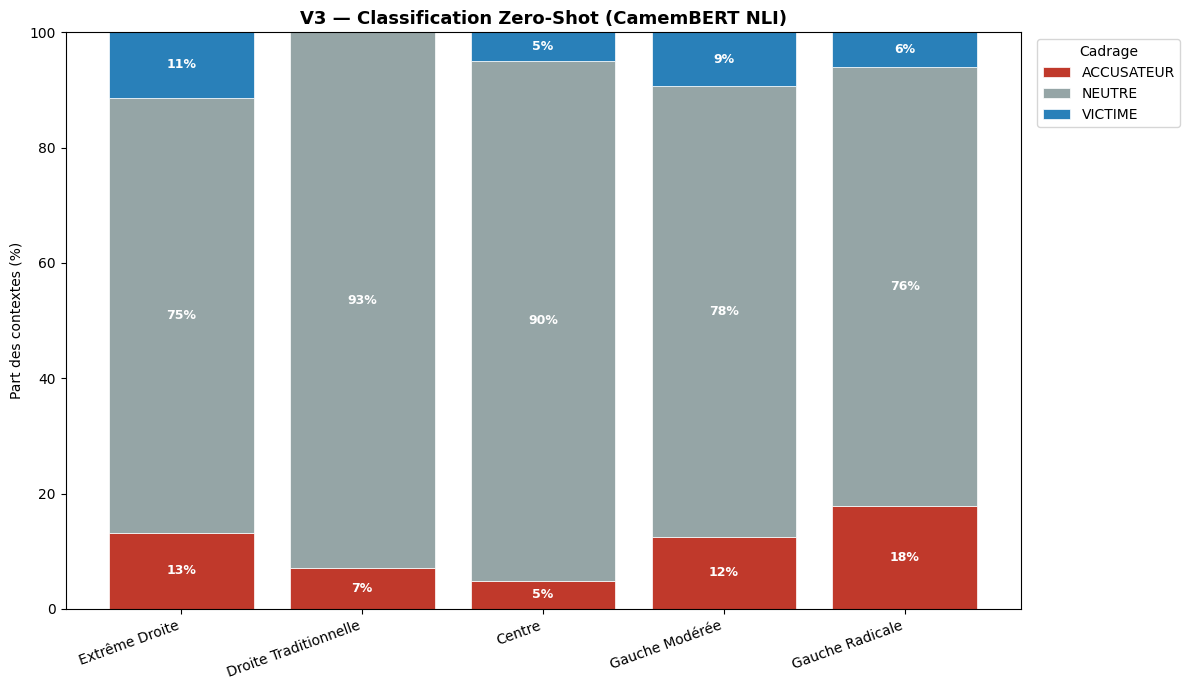

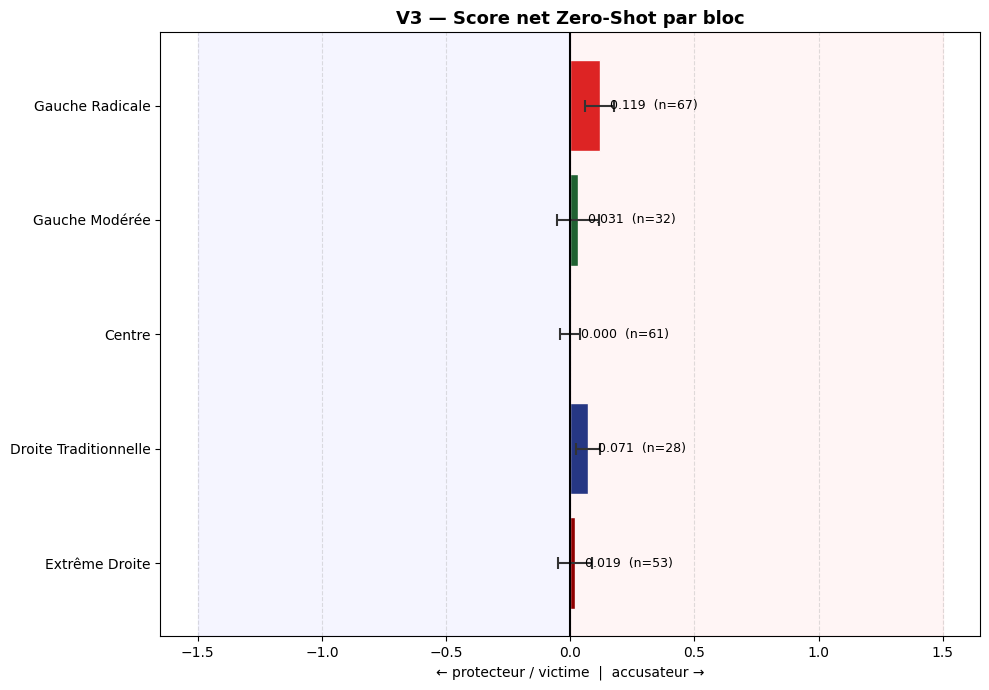

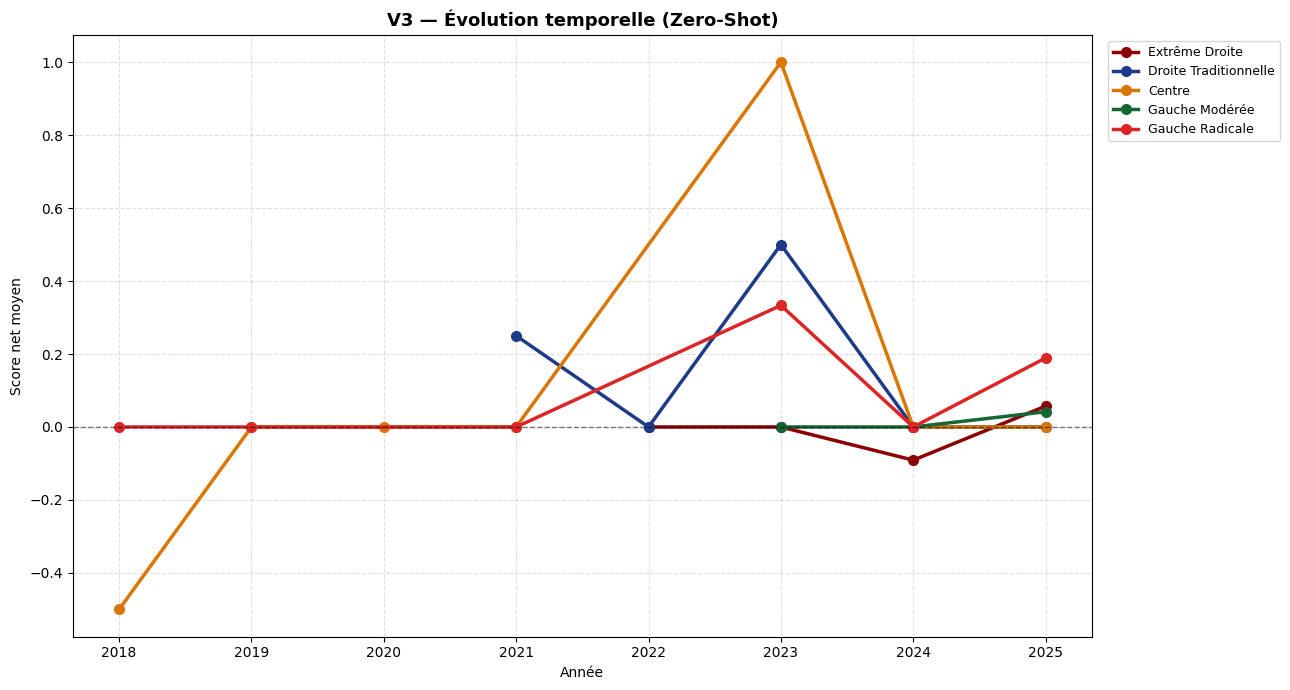


VALIDATION QUALITATIVE — exemples par bloc

─────────────────────────────────────────────────────────────────
  EXTRÊME DROITE — 53 contextes, score net moyen : 0.019
  {'NEUTRE': 40, 'ACCUSATEUR': 7, 'VICTIME': 6}

  [ACCUSATEUR]
    [Rassemblement national] "De toute façon, plus personne n’ignore que votre soutien sans limite à l’immigration est le terreau du communautarisme islamiste, de l’expansion de la charia et de la banalisation du viol..."
    [Rassemblement national] "…et qui s’est illustrée par la défense du Collectif – islamiste – contre l’islamophobie en France (CCIF) et de l’imam antisémite et sexiste Hassan Iquioussen..."

  [VICTIME]
    [Rassemblement national] "En revanche, nous voulons qu’un étranger soit expulsé s’il se rend coupable de proxénétisme, de viol, de meurtre, de harcèlement sexuel aggravé, de diffusion de messages pornographiques à des mineurs, de menace de mort ou encore d’abus de faiblesse s..."
    [Rassemblement national] "Si vous étiez réellement f

In [14]:
tracer_barres_empilees(df_v3, "cadrage_v3",
    titre="V3 — Classification Zero-Shot (CamemBERT NLI)", output_dir=output_v3)
tracer_score_net(df_v3, "score_net_v3",
    titre="V3 — Score net Zero-Shot par bloc", output_dir=output_v3)
tracer_evolution(df_v3, "score_net_v3",
    titre="V3 — Évolution temporelle (Zero-Shot)", output_dir=output_v3)
afficher_exemples(df_v3, "cadrage_v3", n=2)

---
## 5. Méthode V4 — Classification par LLM (Llama via Ollama ENSAE)
---

### Principe

On envoie chaque contexte à un **grand modèle de langue** (LLM) hébergé sur le serveur Ollama de l'ENSAE, avec un prompt structuré qui lui demande :
1. D'**analyser** brièvement le rôle de l'immigration dans la phrase
2. De **classifier** en ACCUSATEUR / VICTIME / NEUTRE

Le prompt inclut des **pièges à éviter** explicites pour améliorer la précision :
- Dénonciation ≠ Accusation (un orateur qui *critique* l'amalgame immigration-VSS n'est pas accusateur)
- Voix passive (un étranger *agressé* est victime, pas agent)
- Mentions administratives (OQTF, droit d'asile) sont neutres

### Infrastructure
- **Serveur** : `https://ollama-api.lab.groupe-genes.fr/api/chat`
- **Modèle** : on liste d'abord les modèles disponibles, puis on choisit `llama3.3` ou `mistral` selon ce qui est installé
- **Reprise automatique** : les résultats sont sauvegardés phrase par phrase dans un CSV. Si le notebook est interrompu (VPN, timeout), il reprend exactement où il s'est arrêté.

> **⏱ Temps estimé** : ~1-3h selon le nombre de contextes et la charge du serveur.
> **⚠️ Nécessite** : connexion au réseau ENSAE / VPN

### 5.1 Détection des modèles disponibles

On interroge le serveur pour voir quels modèles sont installés. C'est exactement la même approche que dans le Testfile original (cellule 29).

In [15]:
import requests
import urllib3

# Désactivation des avertissements SSL (le serveur ENSAE utilise un certificat auto-signé)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

URL_OLLAMA = "https://ollama-api.lab.groupe-genes.fr/api/chat"
url_tags = "https://ollama-api.lab.groupe-genes.fr/api/tags"

try:
    r = requests.get(url_tags, verify=False, timeout=10)
    modeles = r.json().get('models', [])
    print("MODÈLES DISPONIBLES SUR LE SERVEUR DE L'ENSAE :\n")
    for m in modeles:
        print(f"- {m['name']}")
except Exception as e:
    print(f"Erreur de connexion : {e}")
    print("Vérifiez votre connexion VPN ou réseau ENSAE.")
    modeles = []

Erreur de connexion : Expecting value: line 1 column 1 (char 0)
Vérifiez votre connexion VPN ou réseau ENSAE.


### 5.2 Configuration du modèle

On sélectionne le modèle à utiliser. Par défaut on essaie `llama3.3`, sinon `mistral`. Vous pouvez aussi forcer un modèle spécifique en modifiant `MODELE_CHOISI` ci-dessous.

> **Important** : le nom du modèle doit correspondre **exactement** à ce qui est affiché dans la liste ci-dessus. Si le serveur affiche `llama3.3:latest`, il faut utiliser `"llama3.3"` (Ollama résout automatiquement le tag `:latest`).

In [16]:
# ============================================================================
# CHOIX DU MODÈLE — Modifier ici si nécessaire
# ============================================================================
# Mettez le nom exact du modèle tel qu'il apparaît dans la liste ci-dessus
# (sans le ':latest' qui est implicite)

MODELE_CHOISI = "llama3.3"

# --- Vérification automatique ---
noms_modeles = [m['name'] for m in modeles] if modeles else []
modele_trouve = any(MODELE_CHOISI in nom for nom in noms_modeles)

if not modele_trouve and noms_modeles:
    print(f"⚠️ Le modèle '{MODELE_CHOISI}' n'apparaît pas dans la liste du serveur.")
    print(f"   Modèles disponibles : {noms_modeles}")
    # Fallback sur mistral si disponible
    if any("mistral" in nom for nom in noms_modeles):
        MODELE_CHOISI = "mistral"
        print(f"   → Fallback sur '{MODELE_CHOISI}'")
    else:
        print(f"   → On tente quand même avec '{MODELE_CHOISI}' (Ollama résout parfois les alias).")
elif not noms_modeles:
    print(f"⚠️ Impossible de vérifier les modèles (serveur inaccessible).")
    print(f"   On tente avec '{MODELE_CHOISI}'.")
else:
    print(f"✅ Modèle '{MODELE_CHOISI}' trouvé sur le serveur.")

print(f"\n   URL    : {URL_OLLAMA}")
print(f"   Modèle : {MODELE_CHOISI}")

⚠️ Impossible de vérifier les modèles (serveur inaccessible).
   On tente avec 'llama3.3'.

   URL    : https://ollama-api.lab.groupe-genes.fr/api/chat
   Modèle : llama3.3


### 5.3 Fonctions d'appel au LLM

In [17]:
# ============================================================================
# PROMPT SYSTEME — Le cœur de la classification
# ============================================================================

PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire français. "
    "Analyse le contexte fourni (extrait d'un débat à l'Assemblée Nationale) et détermine "
    "le cadrage utilisé par l'orateur concernant le lien entre immigration/minorités et "
    "violences sexistes/sexuelles (VSS).\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique/dénonce l'amalgame immigration-VSS, parle de "
    "  'stigmatisation', 'amalgame', 'récit mensonger', ou défend les immigrés contre des accusations : "
    "  => NEUTRE (l'orateur ne porte PAS l'accusation, il la réfute).\n"
    "- VOIX PASSIVE : Si un étranger ou une minorité 'subit', 'est agressé(e)', 'est victime' "
    "  => VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'éloignement, titres de séjour, droit d'asile, statistiques "
    "  neutres => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases dénonçant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme ou sous-entend que l'immigration ou l'islam CAUSE ou EXPLIQUE les VSS.\n"
    "  VICTIME    : L'orateur présente les immigrés/minorités comme VICTIMES de violences ou discriminations.\n"
    "  NEUTRE     : Réfutation d'amalgame, fait administratif, analyse sans lien causal, contexte anti-raciste.\n\n"

    "REPONSE OBLIGATOIRE en exactement 2 lignes :\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)

# ============================================================================
# FONCTION D'APPEL — Reproduite exactement du Testfile original (cellule 31)
# ============================================================================

def appeler_llm(prompt_user, max_retries=6):
    payload = {
        "model":   MODELE_CHOISI,
        "messages": [
            {"role": "system",  "content": PROMPT_SYSTEME},
            {"role": "user",    "content": prompt_user},
        ],
        "stream":  False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(URL_OLLAMA, json=payload, timeout=90, verify=False)
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code_http = e.response.status_code
            if code_http == 504:
                print(f"\n  [504] Serveur saturé, attente 30s... (tentative {attempt+1}/{max_retries})")
                time.sleep(30)
            elif code_http == 404:
                print(f"\n  ⚠️ Erreur 404. Nouvelle tentative dans 15s... (tentative {attempt+1}/{max_retries})")
                time.sleep(15)
            else:
                print(f"\n  ⚠️ Erreur HTTP {code_http}. Nouvelle tentative dans 10s...")
                time.sleep(10)
        except requests.exceptions.RequestException:
            print(f"\n  ⚠️ Perte de connexion (VPN ?). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
    print("\n  ❌ Échec définitif pour ce contexte après de multiples tentatives. On le saute.")
    return ""


def parser_reponse_llm(reponse):
    """Parse la réponse du LLM pour extraire le cadrage et la justification."""
    cadrage, score_net, justification = "NEUTRE", 0, reponse

    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.IGNORECASE)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net = 1
        elif cadrage == "VICTIME": score_net = -1

    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.IGNORECASE | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()

    return cadrage, score_net, justification

print("✅ Fonctions LLM définies.")

✅ Fonctions LLM définies.


### 5.4 Classification avec reprise CSV

La boucle de classification sauvegarde **chaque résultat immédiatement** dans un CSV. Si le notebook plante (VPN qui tombe, serveur saturé, kernel restart), il suffit de relancer cette cellule : elle détecte automatiquement les phrases déjà traitées et reprend là où elle s'est arrêtée.

C'est la même logique que dans les cellules 30-31 du Testfile original.

In [18]:
output_v4 = os.path.join(DOSSIER_ANALYSES, "cadrage_v4_llm")
os.makedirs(output_v4, exist_ok=True)
fichier_csv_llm = os.path.join(output_v4, "phrases_classifiees_llm.csv")

# --- GESTION DE LA SAUVEGARDE ET REPRISE ---
phrases_deja_faites = []
if os.path.exists(fichier_csv_llm):
    df_existant = pd.read_csv(fichier_csv_llm)
    phrases_deja_faites = df_existant['contexte'].tolist()
    print(f"🔄 Reprise : {len(phrases_deja_faites)} contextes déjà trouvés dans le CSV.")
else:
    # Création du CSV avec les en-têtes
    colonnes = list(df_contextes.columns) + ['cadrage_llm', 'score_net_v4', 'justification', 'reponse_brute']
    pd.DataFrame(columns=colonnes).to_csv(fichier_csv_llm, index=False, encoding='utf-8-sig')

df_a_traiter = df_contextes[~df_contextes['contexte'].isin(phrases_deja_faites)]
print(f"🚀 Il reste {len(df_a_traiter)} contextes à classifier.\n")

# --- BOUCLE DE CLASSIFICATION ---
for index, row in tqdm(df_a_traiter.iterrows(), total=len(df_a_traiter), desc=f"Classification {MODELE_CHOISI}"):
    prompt_user = (
        f"Parti de l'orateur : '{row['nom_parti']}'\n"
        f"Contexte à analyser :\n\"{row['contexte']}\"\n\n"
        "Fournis ton ANALYSE puis ta CATEGORIE."
    )

    reponse = appeler_llm(prompt_user)

    # Si réponse vide après tous les retries, on saute ce contexte (pas d'arrêt total)
    if not reponse:
        continue

    cadrage, score_net, justification = parser_reponse_llm(reponse)

    # Sauvegarde immédiate dans le CSV (mode append, anti-crash)
    nouvelle_ligne = row.to_dict()
    nouvelle_ligne.update({
        'cadrage_llm': cadrage,
        'score_net_v4': score_net,
        'justification': justification,
        'reponse_brute': reponse,
    })
    pd.DataFrame([nouvelle_ligne]).to_csv(
        fichier_csv_llm, mode='a', header=False, index=False, encoding='utf-8-sig'
    )

    time.sleep(0.5)  # Pause entre les requêtes

# --- CHARGEMENT DU RÉSULTAT COMPLET ---
df_v4 = pd.read_csv(fichier_csv_llm)

# Nettoyage
df_v4['cadrage_llm'] = df_v4['cadrage_llm'].astype(str).str.upper().str.strip()
df_v4['cadrage_llm'] = df_v4['cadrage_llm'].where(
    df_v4['cadrage_llm'].isin(['ACCUSATEUR', 'VICTIME', 'NEUTRE']), 'NEUTRE'
)
df_v4['score_net_v4'] = df_v4['cadrage_llm'].map({'ACCUSATEUR': 1, 'VICTIME': -1, 'NEUTRE': 0})

print(f"\n✅ Classification V4 terminée : {len(df_v4)} contextes.")
print(f"\n📊 Distribution V4 :")
print(df_v4['cadrage_llm'].value_counts().to_string())

🔄 Reprise : 0 contextes déjà trouvés dans le CSV.
🚀 Il reste 588 contextes à classifier.



Classification llama3.3:   0%|          | 0/588 [00:00<?, ?it/s]


  ⚠️ Erreur 404. Nouvelle tentative dans 15s... (tentative 1/6)

  ⚠️ Erreur 404. Nouvelle tentative dans 15s... (tentative 2/6)

  ⚠️ Erreur 404. Nouvelle tentative dans 15s... (tentative 3/6)

  ⚠️ Erreur 404. Nouvelle tentative dans 15s... (tentative 4/6)


Classification llama3.3:   0%|          | 0/588 [00:59<?, ?it/s]


KeyboardInterrupt: 

### 5.5 Visualisations V4

In [ ]:
tracer_barres_empilees(df_v4, "cadrage_llm",
    titre=f"V4 — Classification par LLM ({MODELE_CHOISI.upper()})", output_dir=output_v4)
tracer_score_net(df_v4, "score_net_v4",
    titre=f"V4 — Score net LLM par bloc", output_dir=output_v4)
tracer_evolution(df_v4, "score_net_v4",
    titre=f"V4 — Évolution temporelle ({MODELE_CHOISI.upper()})", output_dir=output_v4)

### 5.6 Heatmap par parti et par année (V4)

In [ ]:
d = df_v4.copy()
d["date"] = pd.to_datetime(d["date"], errors="coerce")
d["annee"] = d["date"].dt.year.astype("Int64")

# On garde les partis les plus représentés
top_partis = d["nom_parti"].value_counts().head(12).index.tolist()
d_top = d[d["nom_parti"].isin(top_partis)]

pivot = d_top.groupby(["nom_parti", "annee"])["score_net_v4"].mean().unstack(fill_value=np.nan)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Score net moyen (+ accusateur, − protecteur)"}
)
plt.title(f"Score de cadrage par parti et par année ({MODELE_CHOISI.upper()})")
plt.xlabel("Année")
plt.ylabel("Parti politique")
plt.tight_layout()
plt.savefig(os.path.join(output_v4, "heatmap_partis_llm.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.7 Validation qualitative V4

In [ ]:
afficher_exemples(df_v4, "cadrage_llm", n=3)

---
## 6. Synthèse comparative des 4 méthodes
---

On compare les résultats des 4 méthodes sur les mêmes données pour voir si elles convergent — ce qui renforcerait la robustesse des conclusions.

In [ ]:
# Fusion des résultats des 4 méthodes
print("📊 SYNTHÈSE COMPARATIVE DES 4 MÉTHODES")
print("=" * 80)

for nom, df_m, col_cadrage in [
    ("V1 — Lexique", df_v1, "cadrage_v1"),
    ("V2 — Regex", df_v2, "cadrage_v2"),
    ("V3 — Zero-Shot", df_v3, "cadrage_v3"),
    ("V4 — LLM", df_v4, "cadrage_llm"),
]:
    print(f"\n{nom}")
    print("-" * 40)
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        if sub.empty:
            continue
        n = len(sub)
        pct_acc = (sub[col_cadrage] == "ACCUSATEUR").mean() * 100
        pct_vic = (sub[col_cadrage] == "VICTIME").mean() * 100
        pct_neu = (sub[col_cadrage] == "NEUTRE").mean() * 100
        print(f"  {bloc:30s} : ACC={pct_acc:5.1f}%  VIC={pct_vic:5.1f}%  NEU={pct_neu:5.1f}%  (n={n})")

In [ ]:
# Graphique de synthèse : % ACCUSATEUR par bloc pour chaque méthode
fig, ax = plt.subplots(figsize=(14, 7))

methodes_data = [
    ("V1\nLexique", df_v1, "cadrage_v1"),
    ("V2\nRegex", df_v2, "cadrage_v2"),
    ("V3\nZero-Shot", df_v3, "cadrage_v3"),
    ("V4\nLLM", df_v4, "cadrage_llm"),
]

x = np.arange(len(ORDRE_BLOCS))
width = 0.18

for i, (nom, df_m, col) in enumerate(methodes_data):
    pct_acc = []
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        if len(sub) > 0:
            pct_acc.append((sub[col] == "ACCUSATEUR").mean() * 100)
        else:
            pct_acc.append(0)
    ax.bar(x + i * width, pct_acc, width, label=nom, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ORDRE_BLOCS, rotation=15, ha="right")
ax.set_ylabel("% de phrases classées ACCUSATEUR")
ax.set_title("Comparaison des 4 méthodes : % de cadrage accusateur par bloc", fontsize=13, fontweight="bold")
ax.legend(title="Méthode")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(DOSSIER_ANALYSES, "comparaison_4_methodes.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Conclusion

Les 4 méthodes, malgré des approches très différentes (lexicale, syntaxique, sémantique, générative), devraient converger sur les grandes tendances :
- L'**Extrême Droite** devrait avoir le taux le plus élevé de cadrage accusateur
- La **Gauche Radicale** devrait avoir le taux le plus élevé de cadrage victime/protecteur
- Les **blocs intermédiaires** (Droite Traditionnelle, Centre) révèlent les dynamiques de convergence ou de résistance au cadrage fémonationaliste

Si les méthodes divergent fortement sur un bloc, cela signale que le discours de ce bloc est **ambigu** — c'est-à-dire qu'il utilise un vocabulaire qui peut être interprété différemment selon la méthode d'analyse, ce qui est en soi un résultat intéressant.